## Computational Finance Lab Assignment 7
### Regression Methods and Pricing of American Options
#### Aleksandra Górska, Marcin Pałyga


## Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from numpy.polynomial.hermite import hermval

sns.set_theme()

## Task 1

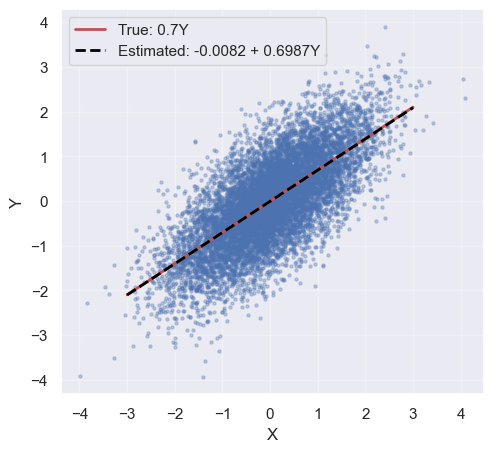

In [12]:
M = 10000
rho = 0.7
mean = np.zeros(2)
cov = np.array([[1, rho], [rho, 1]])
X, Y = np.random.multivariate_normal(mean, cov, M).T

Ms = [100, 500, 1000, 5000, 10000]
A = np.column_stack((np.ones(M), Y))
beta = np.linalg.lstsq(A, X, rcond=None)[0]
y_grid = np.linspace(-3, 3, 100)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(Y, X, s=5, alpha=0.3)
plt.plot(y_grid, rho * y_grid, lw=2, label=f"True: {rho}Y", c='r')
plt.plot(y_grid, beta[0] + beta[1] * y_grid, "--", lw=2,
            label=f"Estimated: {beta[0]:.4f} + {beta[1]:.4f}Y", c='black')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(alpha=0.3)


M=  100: Estimated slope = 0.674007, Error = 0.025993
M=  500: Estimated slope = 0.697590, Error = 0.002410
M= 1000: Estimated slope = 0.682611, Error = 0.017389
M= 5000: Estimated slope = 0.709203, Error = 0.009203
M=10000: Estimated slope = 0.691414, Error = 0.008586


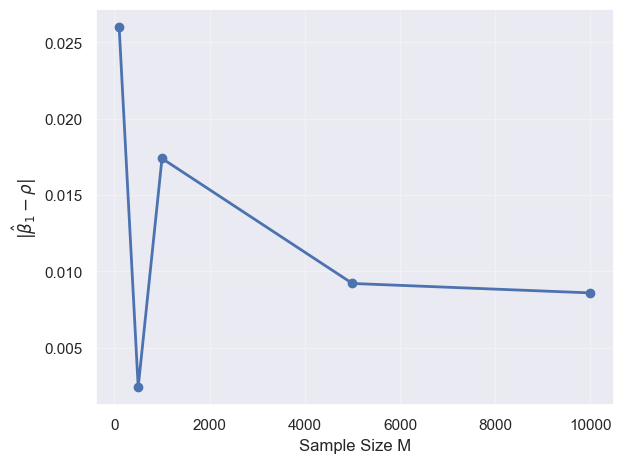

In [13]:
errors = []
for M in Ms:
    X, Y = np.random.multivariate_normal(mean, cov, M).T
    A = np.column_stack((np.ones(M), Y))
    beta = np.linalg.lstsq(A, X, rcond=None)[0]
    errors.append(abs(beta[1] - rho))
    print(f"M={M:5d}: Estimated slope = {beta[1]:.6f}, Error = {abs(beta[1]-rho):.6f}")

plt.plot(Ms, errors, "o-", lw=2)
plt.xlabel("Sample Size M")
plt.ylabel(r"$|\hat\beta_1 - \rho|$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Task 2

In [14]:
class AmericanPutPricer:
    def __init__(self, S0, K, T, r, sigma, N):
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.N = N
        self.dt = T / N

    def simulate(self, M):
        S = np.zeros((M, self.N + 1))
        S[:, 0] = self.S0

        for t in range(self.N):
            Z = np.random.randn(M)
            S[:, t+1] = S[:, t] * np.exp(
                (self.r - 0.5*self.sigma**2)*self.dt
                + self.sigma*np.sqrt(self.dt)*Z
            )
        return S
    
    def payoff(self, S):
        return np.maximum(self.K - S, 0)

    def rescale(self, S):
        return (S - self.S0) / self.S0

    def hermite_basis(self, x, degree):
        Phi = np.zeros((len(x), degree + 1))
        for d in range(degree + 1):
            c = np.zeros(d + 1)
            c[d] = 1
            Phi[:, d] = hermval(x, c)
        return Phi
    
    def binomial_price(self, steps=1000):
        dt = self.T/steps
        u = np.exp(self.sigma*np.sqrt(dt))
        d = 1/u
        p = (np.exp(self.r*dt)-d)/(u-d)
        disc = np.exp(-self.r*dt)   
        prices = np.array([self.S0*(u**(steps-i))*(d**i) for i in range(steps+1)])
        payoffs = self.payoff(prices)
        for j in range(steps-1, -1, -1):
            prices = np.array([self.S0*(u**(j-i))*(d**i) for i in range(j+1)])
            hold = disc*(p*payoffs[:-1] + (1-p)*payoffs[1:])
            exercise = self.payoff(prices)
            payoffs = np.maximum(exercise, hold)
        return payoffs[0]
    
    def value_iteration(self, M, degree, rescale=True):
        S = self.simulate(M)
        cash = self.payoff(S[:, -1])
        for t in range(self.N-1, 0, -1):
            itm = S[:, t] < self.K
            if not np.any(itm):
                continue
            X = self.rescale(S[itm, t]) if rescale else S[itm, t]
            Y = cash[itm] * np.exp(-self.r*self.dt)
            Phi = self.hermite_basis(X, degree)
            beta = np.linalg.lstsq(Phi, Y, rcond=None)[0]
            cont = Phi @ beta
            exercise = self.payoff(S[itm, t]) > cont
            cash[itm] = np.where(exercise, self.payoff(S[itm, t]), cash[itm])
        return np.mean(cash) * np.exp(-self.r*self.dt)
    
    

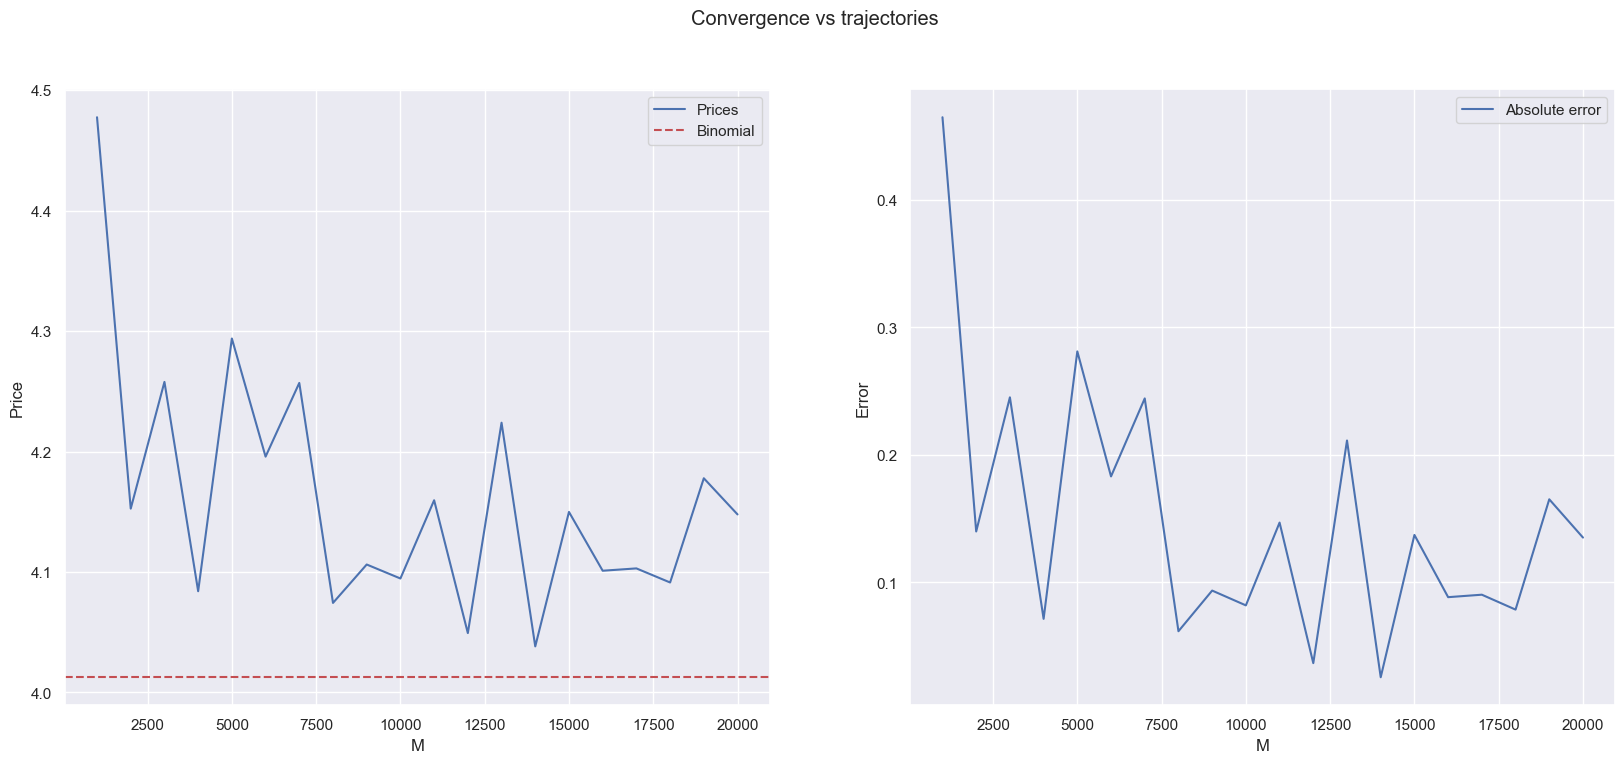

In [44]:
pricer = AmericanPutPricer(100, 95, 1, 0.05, 0.2, 1000)
d = 2
Ms= [1000*i for i in range(1,21)]
results = []
binomial_price = pricer.binomial_price(steps=1000)
for M in Ms:
    results.append(pricer.value_iteration(M, d, False))
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax[0].plot(Ms, results, label='Prices')
ax[0].axhline(binomial_price, color="r", ls="--", label="Binomial")
ax[0].set_xlabel("M")
ax[0].set_ylabel("Price")
ax[0].legend()
errors = np.abs(np.array(results) - binomial_price)
ax[1].plot(Ms, errors, label="Absolute error")
ax[1].set_xlabel("M")
ax[1].set_ylabel("Error")
ax[1].legend()
plt.suptitle("Convergence vs trajectories")
plt.show()

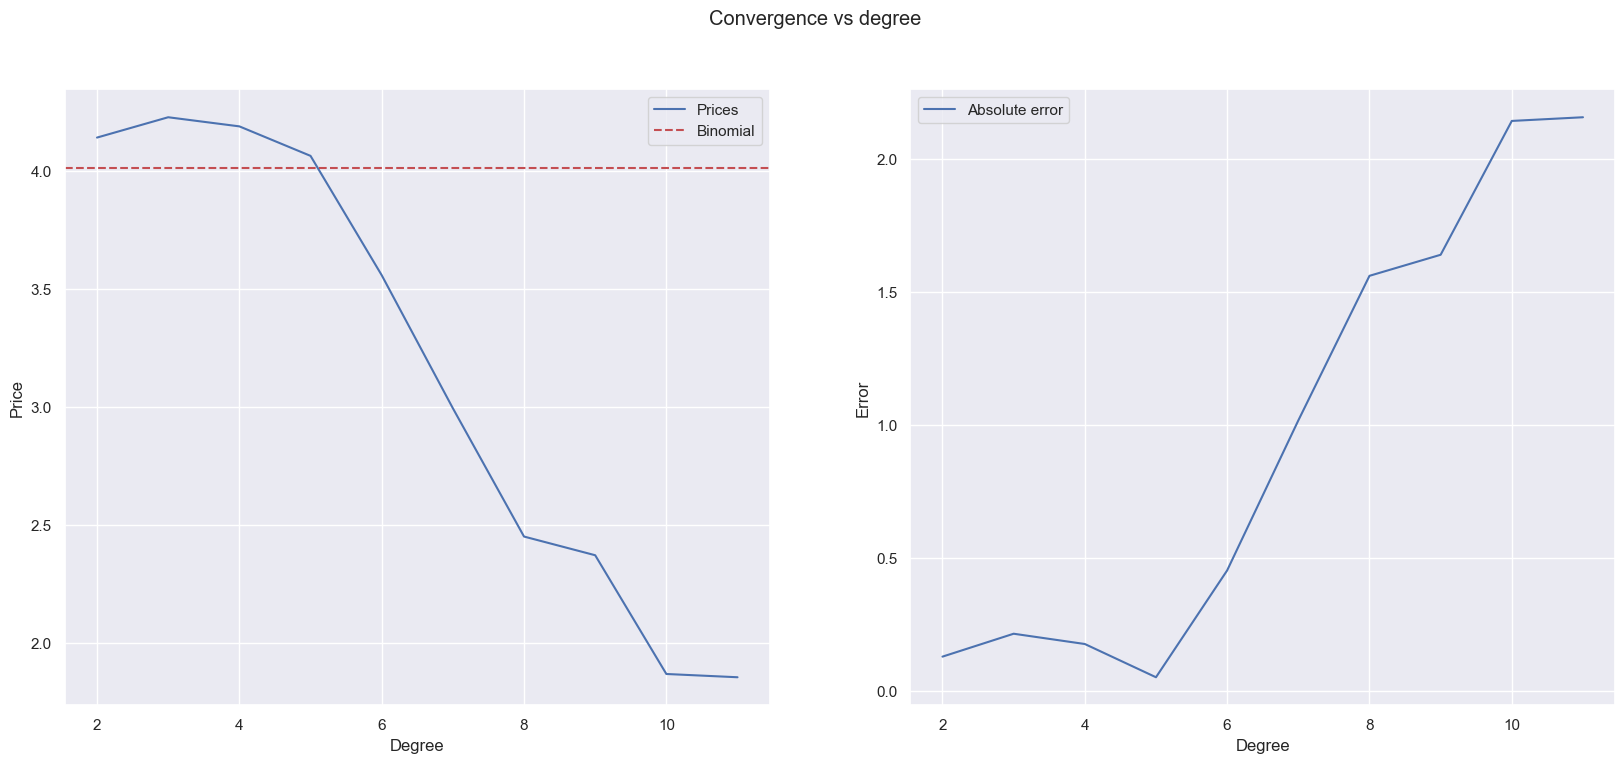

In [43]:
pricer = AmericanPutPricer(100, 95, 1, 0.05, 0.2, 1000)
ds = range(2,12)
M = 10000
results = []
binomial_price = pricer.binomial_price(steps=1000)
for d in ds:
    results.append(pricer.value_iteration(M, d, False))
fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].plot(ds, results, label='Prices')
ax[0].axhline(binomial_price, color="r", ls="--", label="Binomial")
ax[0].set_xlabel("Degree")
ax[0].set_ylabel("Price")
ax[0].legend()
errors = np.abs(np.array(results) - binomial_price)
ax[1].plot(ds, errors, label="Absolute error")
ax[1].set_xlabel("Degree")
ax[1].set_ylabel("Error")
ax[1].legend()
plt.suptitle("Convergence vs degree")
plt.show()

In [40]:
pricer = AmericanPutPricer(100, 95, 1, 0.05, 0.2, 1000)
d = 4
M = 10000
no_rescaling = pricer.value_iteration(M, d, False)
rescaling = pricer.value_iteration(M, d, True)
binomial_price = pricer.binomial_price(steps=1000)
print(f"Price with rescaling {rescaling:.4f} vs benchmark price {binomial_price:.4f}, error: {np.abs(rescaling-binomial_price):.4f}")
print(f"Price without rescaling: {no_rescaling:.4f} vs benchmark price {binomial_price:.4f}, error: {np.abs(no_rescaling-binomial_price):.4f}")


Price with rescaling 4.0830 vs benchmark price 4.0126, error: 0.0704
Price without rescaling: 4.2409 vs benchmark price 4.0126, error: 0.2283


## Task 3

In [28]:
class LSPricer:
    def __init__(self, S0, K, T, r, sigma, N):
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.N = N
        self.dt = T / N

    def simulate(self, M):
        S = np.zeros((M, self.N + 1))
        S[:, 0] = self.S0

        for t in range(self.N):
            Z = np.random.randn(M)
            S[:, t+1] = S[:, t] * np.exp(
                (self.r - 0.5*self.sigma**2)*self.dt
                + self.sigma*np.sqrt(self.dt)*Z
            )
        return S
    
    def payoff(self, S):
        return np.maximum(self.K - S, 0)

    def rescale(self, S):
        return (S - self.S0) / self.S0

    def hermite_basis(self, x, degree):
        Phi = np.zeros((len(x), degree + 1))
        for d in range(degree + 1):
            c = np.zeros(d + 1)
            c[d] = 1
            Phi[:, d] = hermval(x, c)
        return Phi
    
    def binomial_price(self, steps=1000):
        dt = self.T/steps
        u = np.exp(self.sigma*np.sqrt(dt))
        d = 1/u
        p = (np.exp(self.r*dt)-d)/(u-d)
        disc = np.exp(-self.r*dt)   
        prices = np.array([self.S0*(u**(steps-i))*(d**i) for i in range(steps+1)])
        payoffs = self.payoff(prices)
        for j in range(steps-1, -1, -1):
            prices = np.array([self.S0*(u**(j-i))*(d**i) for i in range(j+1)])
            hold = disc*(p*payoffs[:-1] + (1-p)*payoffs[1:])
            exercise = self.payoff(prices)
            payoffs = np.maximum(exercise, hold)
        return payoffs[0]
    
    def longstaff_schwartz(self, M, n_basis, use_rescaling=True):
        paths = self.simulate(M)
        exercise_times = np.full(M, self.N)
        for t in range(self.N - 1, 0, -1):
            S_t = paths[:, t]
            itm = S_t < self.K
            if np.sum(itm) == 0:
                continue
            if use_rescaling:
                X = self.rescale(S_t[itm])
            else:
                X = S_t[itm]
            discount_factors = np.exp(-self.r * self.dt * (exercise_times[itm] - t))
            future_cash_flows = self.payoff(paths[itm, exercise_times[itm]]) * discount_factors
            basis = self.hermite_basis(X, n_basis)
            try:
                beta = np.linalg.lstsq(basis, future_cash_flows, rcond=None)[0]
                continuation_value = basis @ beta
            except:
                continuation_value = future_cash_flows
            exercise_value = self.payoff(S_t[itm])
            early_exercise = exercise_value > continuation_value
            itm_indices = np.where(itm)[0]
            exercise_times[itm_indices[early_exercise]] = t
        discount_factors = np.exp(-self.r * self.dt * exercise_times)
        cash_flows = self.payoff(paths[np.arange(M), exercise_times]) * discount_factors
        option_price = np.mean(cash_flows)
        return option_price

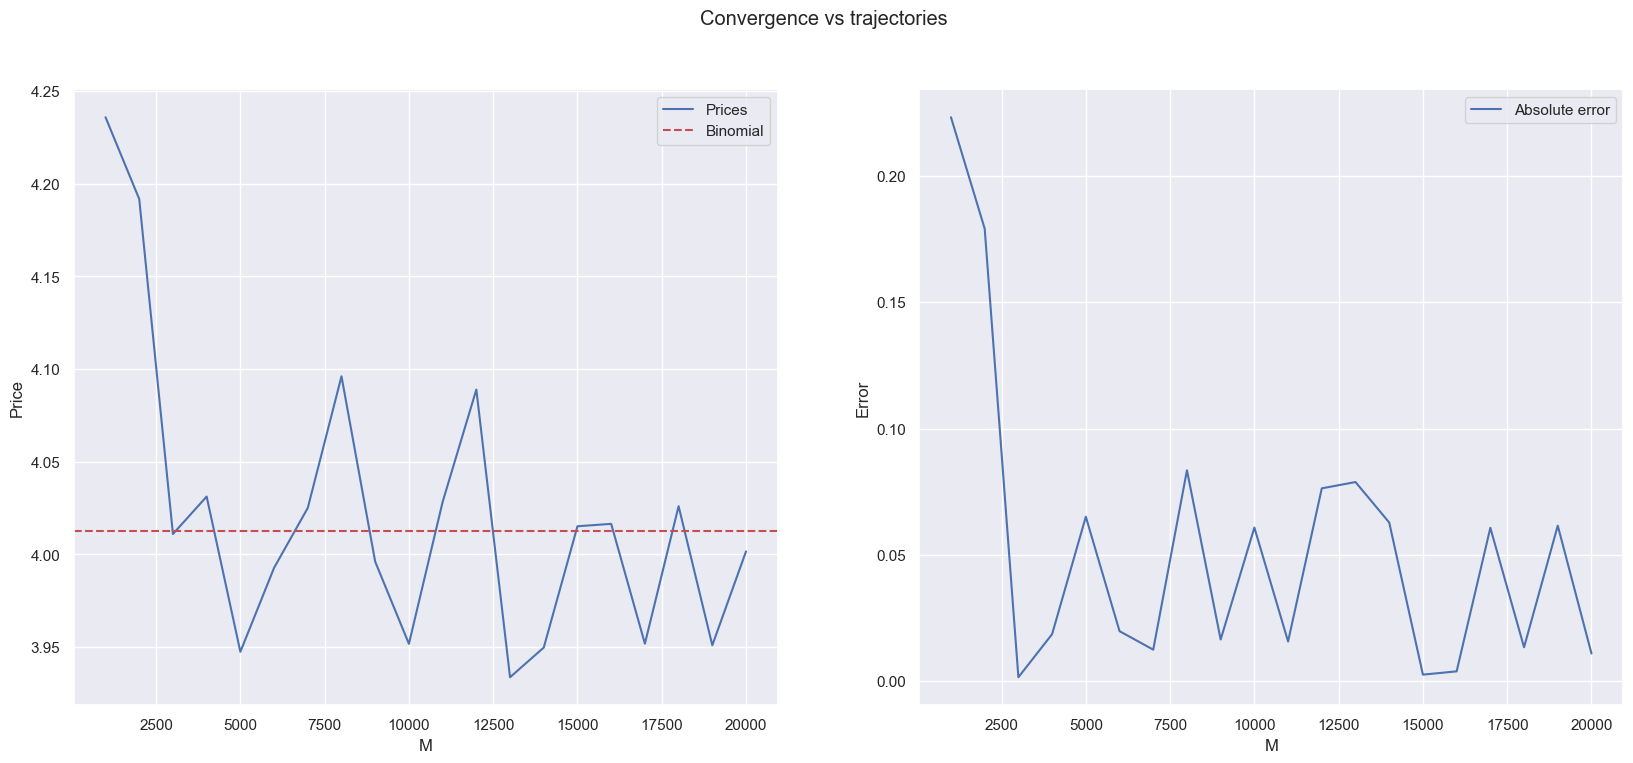

In [42]:
pricer = LSPricer(100, 95, 1, 0.05, 0.2, 1000)
d = 2
Ms= [1000*i for i in range(1,21)]
results = []
binomial_price = pricer.binomial_price(steps=1000)
for M in Ms:
    results.append(pricer.longstaff_schwartz(M, d, True))
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax[0].plot(Ms, results, label='Prices')
ax[0].axhline(binomial_price, color="r", ls="--", label="Binomial")
ax[0].set_xlabel("M")
ax[0].set_ylabel("Price")
ax[0].legend()
errors = np.abs(np.array(results) - binomial_price)
ax[1].plot(Ms, errors, label="Absolute error")
ax[1].set_xlabel("M")
ax[1].set_ylabel("Error")
ax[1].legend()
plt.suptitle("Convergence vs trajectories")
plt.show()

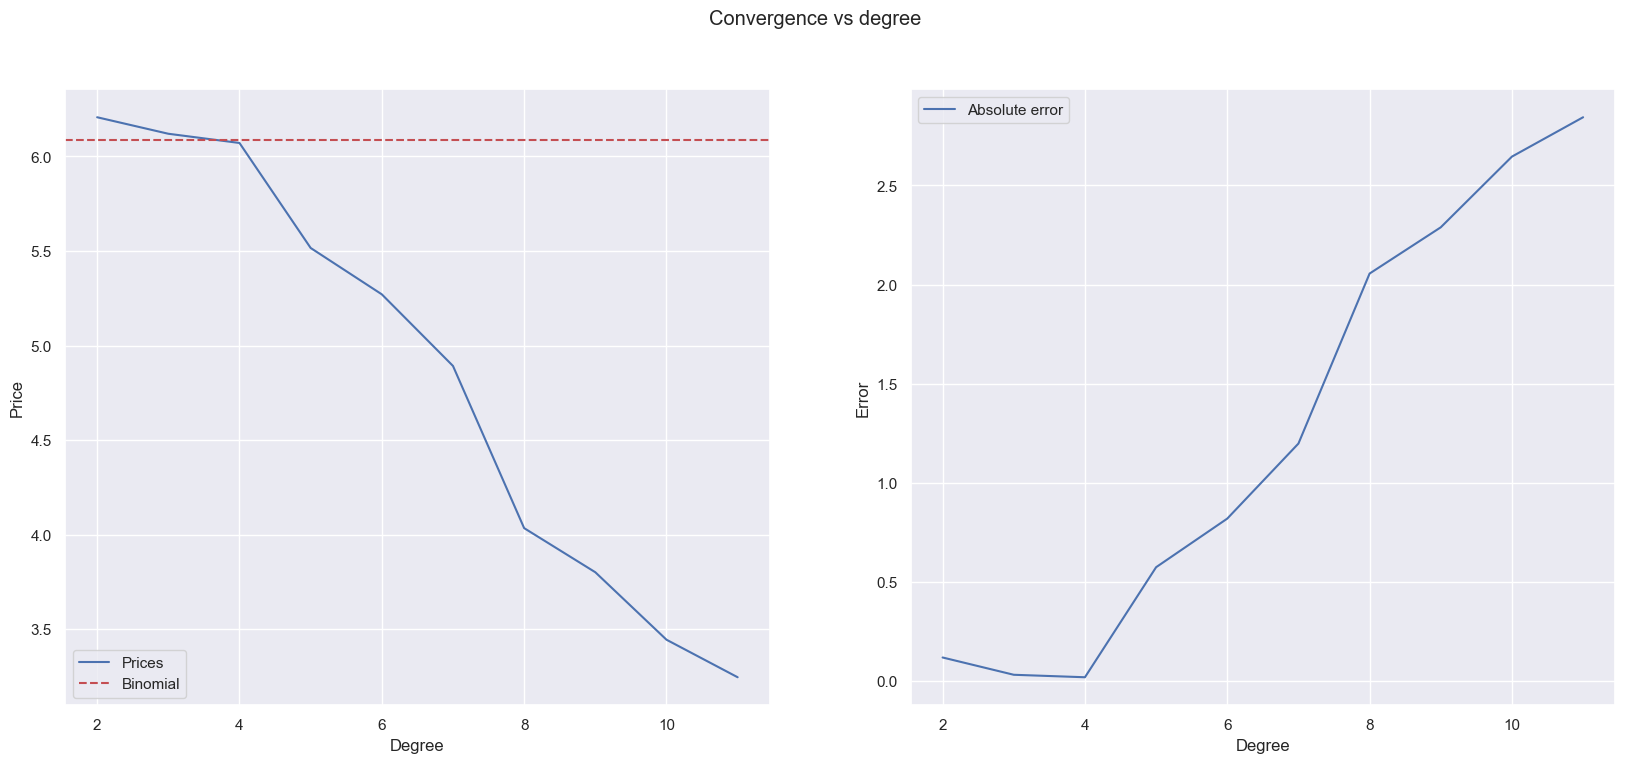

In [41]:
pricer = LSPricer(100, 100, 1, 0.05, 0.2, 1000)
ds = range(2,12)
M = 10000
results = []
binomial_price = pricer.binomial_price(steps=1000)
for d in ds:
    results.append(pricer.longstaff_schwartz(M, d, False))
fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].plot(ds, results, label='Prices')
ax[0].axhline(binomial_price, color="r", ls="--", label="Binomial")
ax[0].set_xlabel("Degree")
ax[0].set_ylabel("Price")
ax[0].legend()
errors = np.abs(np.array(results) - binomial_price)
ax[1].plot(ds, errors, label="Absolute error")
ax[1].set_xlabel("Degree")
ax[1].set_ylabel("Error")
ax[1].legend()
plt.suptitle("Convergence vs degree")
plt.show()

In [30]:
M = 10000
d = 4
pricer = LSPricer(100, 95, 1, 0.05, 0.2, 1000)
LS_price = pricer.longstaff_schwartz(M, d, True)
pricer = AmericanPutPricer(100, 95, 1, 0.05, 0.2, 1000)
AP_price = pricer.value_iteration(M, d, True)
bn_price = pricer.binomial_price(1000)
print(f"Price using Longstaff-Schwartz {LS_price:.4f} vs benchmark price {bn_price:.4f}, error: {np.abs(LS_price-bn_price):.4f}")
print(f"Price using Value Iteration: {AP_price:.4f} vs benchmark price {bn_price:.4f}, error: {np.abs(AP_price-bn_price):.4f}")

Price using Longstaff-Schwartz 3.9791 vs benchmark price 4.0126, error: 0.0335
Price using Value Iteration: 4.2132 vs benchmark price 4.0126, error: 0.2006
